In [18]:
using ITensors, ITensorMPS
using SparseArrays
using LinearAlgebra
using Plots
using JLD2
using LaTeXStrings
using Glob
using StatsBase

In [11]:
using JLD2
using Glob

"""
Load sample_*.jld2 files from `outdir` and combine data across
samples and repeated jobs.

Files missing required keys (including "mode") are skipped.

Returns:
  combined :: Dict{NamedTuple, Dict{Symbol, Any}}
  skipped  :: Vector{String}
"""
function load_and_combine(outdir::String)
    files = glob("sample_*.jld2", outdir)

    combined = Dict{NamedTuple, Dict{Symbol, Any}}()
    skipped  = String[]

    for f in files
        d = load(f)

        # hard requirements
        if !(haskey(d, "L") &&
             haskey(d, "T") &&
             haskey(d, "p") &&
             haskey(d, "mode") &&
             haskey(d, "data"))
            push!(skipped, f)
            continue
        end

        # optional but expected
        t = get(d, "t", 1)

        key = (
            L    = d["L"],
            T    = d["T"],
            p    = d["p"],
            mode = d["mode"],
            t    = t,
        )

        data = d["data"]  # Dict or NamedTuple

        if !haskey(combined, key)
            combined[key] = Dict(
                obs => deepcopy(val) for (obs, val) in pairs(data)
            )
        else
            for (obs, val) in pairs(data)
                old = combined[key][obs]

                if isa(old, AbstractArray) && isa(val, AbstractArray)
                    combined[key][obs] = vcat(old, val)
                else
                    error("Cannot combine observable $obs in file $f")
                end
            end
        end
    end

    return combined, skipped
end

# Example usage
outdir = joinpath(@__DIR__, "../output")
combined, skipped = load_and_combine(outdir)

@show length(skipped)


length(skipped) = 24


24

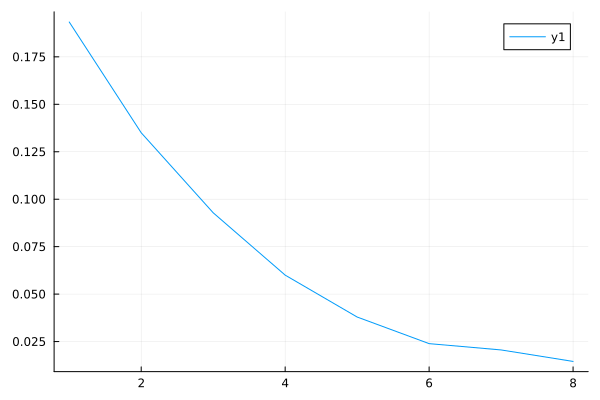

In [62]:
L = 16
T = 10L
p = 0.1
plot(reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_sampled", t=L)][:κ1_corrs_sampled], dims=1)[1,:]))

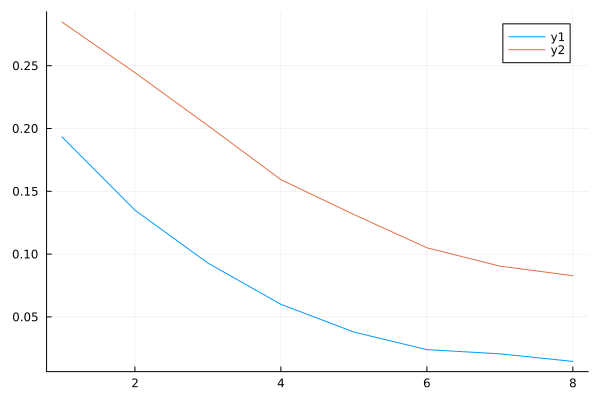

In [63]:
plot!(reverse(mean(combined[(L=L, T=T, p=p, mode="renyi1_TCI", t=L)][:κ1_corrs_TCI], dims=1)[1,:]))